In [8]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import os
import tensorflow as tf

In [26]:
def D_JS(p1,p2,tol=1e-16):
    p1=p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [27]:
# minorized reference
with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    dft_d = file['density'][:]

with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_ref_mean.h5', 'r') as file:
    VMC_ref = file['density'][:]

data = np.load("/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/Data_Gen/DFT_W_N/Aug/DFT_dat_lev_2451270000000000_sample_training_data_Aug.npz")
x_train = data['x_train']
x_val   = data['x_val']
y_train = data['y_train']
y_val   = data['y_val']
n_samples = data["total_samples"]


data = 0
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000655360.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]

In [28]:
#Transform density
def transform(density,density_ref,transform_type):
    dens = density
    dref  = density_ref
    ttype = transform_type
    if ttype=='value':
        dtrans = density
    elif ttype=='sqrt':
        dtrans = np.sqrt(np.abs(density))
    elif ttype=='log':
        dtrans  = np.log(np.abs(density))
    elif ttype=='residual_noise':
        dval  = dref
        dsqrt = np.sqrt(np.abs(dref))
        dtrans = (dens-dval)/dsqrt
    else:
        raise RuntimeError('bad transform type')
    return dtrans


def inverse_transform(density_trans,density_ref,transform_type):
    dref   = density_ref
    ttype  = transform_type
    dtrans = density_trans
    if ttype=='value':
        density = dtrans
    elif ttype=='sqrt':
        density = dtrans**2
    elif ttype=='log':
        density = np.log(np.abs(dtrans))
    elif ttype=='residual_noise':
        dval  = dref
        dsqrt = np.sqrt(np.abs(dref))
        density = dval + dsqrt*dtrans
    else:
        raise RuntimeError('bad transform type')
    return density


In [29]:
# ======================================================
# 1. LOAD DFT REFERENCE
# ======================================================
dft_path ='/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5'
with h5py.File(dft_path, 'r') as file:
    dft_d = file['density'][:]

# Reshape DFT to (1, 116, 116, 72, 1) for easy broadcasting
dft_ref_broadcast = dft_d[np.newaxis, ..., np.newaxis]

# ======================================================
# 2. LOAD TRAINING DATA
# ======================================================
# Assuming 'data' dictionary is already loaded as per your snippet
# x_train shape: (N, 116, 116, 72, 1)

print(">>> Transforming Training Data to Residual Space...")
# Apply transform: (X - DFT) / sqrt(DFT)
x_train_trans = transform(x_train, dft_ref_broadcast, 'residual_noise')
y_train_trans = transform(y_train, dft_ref_broadcast, 'residual_noise')

x_val_trans   = transform(x_val,   dft_ref_broadcast, 'residual_noise')
y_val_trans   = transform(y_val,   dft_ref_broadcast, 'residual_noise')

print(f"Data Transformed. New Range: [{np.min(x_train_trans):.2f}, {np.max(x_train_trans):.2f}]")
# Note: The range should be roughly [-5, 5] or [-10, 10] if the physics holds up.

>>> Transforming Training Data to Residual Space...


ValueError: operands could not be broadcast together with shapes (1000,64,64,64) (1,64,64,64,1) 

In [17]:
import numpy as np
import os

def encode_voxel_to_rgb(x_train_3d, x_val_3d, x_test_3d,
                        y_train_3d, y_val_3d, y_test_3d,
                        ref_d=None, save_dir='scalers'):
    """
    Encode a batch of 3D volumes by normalizing each depth slice independently and replicating to RGB.
    Each input of shape (N, 64, 64, 64) is transformed into (N*64, 64, 64, 3).

    Args:
        *_3d: ndarray of shape (N, 64, 64, 64)
        ref_d: optional ndarray of shape (64, 64, 64)
        save_dir: directory to save the (min, max) scalers for each batch

    Returns:
        Tuple of:
            x_train_rgb, x_val_rgb, x_test_rgb,
            y_train_rgb, y_val_rgb, y_test_rgb,
            ref_d_rgb (or None if not provided)
    """
    os.makedirs(save_dir, exist_ok=True)

    def process_batch(batch, tag):
        N, D, H, W = batch.shape  # (N, 64, 64, 64)
        rgb_batch = np.zeros((N * D, H, W, 3), dtype=np.float32)
        all_mins = []
        all_maxs = []

        for i in range(N):
            mins = []
            maxs = []
            for d in range(D):
                slice_2d = batch[i, d, :, :]
                s_min = float(slice_2d.min())
                s_max = float(slice_2d.max())

                if s_max == s_min:
                    s_max = s_min + 1e-6  # prevent divide-by-zero

                normed = (slice_2d - s_min) / (s_max - s_min)
                rgb = np.stack([normed] * 3, axis=-1)  # shape: (64, 64, 3)

                rgb_batch[i * D + d] = rgb
                mins.append(s_min)
                maxs.append(s_max)

            all_mins.append(mins)
            all_maxs.append(maxs)

        np.savez(os.path.join(save_dir, f'{tag}_scalers.npz'),
                 mins=np.array(all_mins), maxs=np.array(all_maxs))

        return rgb_batch

    x_train_rgb = process_batch(x_train_3d, 'x_train')
    x_val_rgb   = process_batch(x_val_3d, 'x_val')

    y_train_rgb = process_batch(y_train_3d, 'y_train')
    y_val_rgb   = process_batch(y_val_3d, 'y_val')


    # Optional: single ref volume
    ref_d_rgb = None
    if ref_d is not None:
        ref_rgb = np.zeros((64, 64, 64, 3), dtype=np.float32)
        ref_mins = []
        ref_maxs = []
        for d in range(64):
            slice_2d = ref_d[d, :, :]
            s_min = float(slice_2d.min())
            s_max = float(slice_2d.max())

            if s_max == s_min:
                s_max = s_min + 1e-6

            normed = (slice_2d - s_min) / (s_max - s_min)
            ref_rgb[d] = np.stack([normed] * 3, axis=-1)
            ref_mins.append(s_min)
            ref_maxs.append(s_max)

        np.savez(os.path.join(save_dir, 'ref_d_scalers.npz'),
                 mins=np.array(ref_mins), maxs=np.array(ref_maxs))
        ref_d_rgb = ref_rgb

    return (
        x_train_rgb, x_val_rgb, None,
        y_train_rgb, y_val_rgb, None,
        ref_d_rgb
    )


In [18]:
import numpy as np

def decode_rgb_to_voxel_batch(rgb_data, scaler_path):
    """
    Decode RGB-encoded batch (N*64, 64, 64, 3) back to original (N, 64, 64, 64) data
    using per-slice min/max scalers.

    Args:
        rgb_data: ndarray of shape (N*64, 64, 64, 3)
        scaler_path: path to `.npz` file containing 'mins' and 'maxs' arrays
                     of shape (N, 64)

    Returns:
        reconstructed: ndarray of shape (N, 64, 64, 64)
    """
    num_slices = 64
    assert rgb_data.ndim == 4 and rgb_data.shape[1:4] == (64, 64, 3), \
        f"Expected shape (N*64, 64, 64, 3), got {rgb_data.shape}"

    N = rgb_data.shape[0] // num_slices
    assert rgb_data.shape[0] == N * num_slices, "RGB data is not a multiple of 64 slices"

    scalers = np.load(scaler_path)
    mins = scalers['mins']  # shape (N, 64)
    maxs = scalers['maxs']  # shape (N, 64)

    reconstructed = np.zeros((N, 64, 64, 64), dtype=np.float32)

    for i in range(N):
        for d in range(num_slices):
            idx = i * num_slices + d
            normed = rgb_data[idx, :, :, 0]  # Use first channel (R), they are all the same
            s_min = mins[i, d]
            s_max = maxs[i, d]
            reconstructed[i, d, :, :] = normed * (s_max - s_min) + s_min

    return reconstructed


In [19]:
print(x_train.shape)

(1000, 64, 64, 64)


In [22]:
x_train_rgb, x_val_rgb, x_test_rgb, \
y_train_rgb, y_val_rgb, y_test_rgb, \
ref_d_rgb = encode_voxel_to_rgb(
    x_train, x_val, None,
    y_train, y_val, None,
    ref_d=VMC_ref 
)
print("done generating")

done generating


In [13]:
# Decode the full batch
x_train_decoded = decode_rgb_to_density2d_batch(
    x_train_rgb,
    scaler_path='scalers_2d/x_train_scalers.npz'
)

# Pick one example
i = 0
orig = x_train[i]
rec  = x_train_decoded[i]
abs_err = np.abs(orig - rec)

print("Max abs error: ", abs_err.max())
print("Mean abs error:", abs_err.mean())

print("Original sum:  ", orig.sum())
print("Decoded sum:   ", rec.sum())


Max abs error:  3.776380215481101e-10
Mean abs error: 5.3912311486963056e-11
Original sum:   7.999999999980929
Decoded sum:    8.0


In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt

# ============================================================
# Simple 2D bottleneck autoencoder
# ============================================================
def create_simple_bottleneck_ae(input_shape=(64, 64, 1), latent_dim=128):

    inp = layers.Input(shape=input_shape)

    # -------- Encoder --------
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = layers.MaxPooling2D(2)(x)          # 32×32

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)          # 16×16

    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, activation='relu')(x)

    # -------- Decoder --------
    x = layers.Dense(16 * 16 * 64, activation='relu')(latent)
    x = layers.Reshape((16, 16, 64))(x)

    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)

    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)

    out = layers.Conv2D(1, 3, padding='same', activation='linear')(x)

    return models.Model(inp, out)


# ============================================================
# Training pipeline
# ============================================================
if __name__ == "__main__":

    cae = create_simple_bottleneck_ae(
        input_shape=(64, 64, 1),
        latent_dim=128
    )

    cae.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="mae"
    )

    cae.summary()

    callbacks_list = [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]

    cae.fit(
        x_train[..., None],
        y_train[..., None],
        validation_data=(x_val[..., None], y_val[..., None]),
        epochs=50,
        batch_size=32,
        callbacks=callbacks_list,
        verbose=1
    )

    #cae.save(f"{n_samples}_minor_CAE_IMG_enc.keras")


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16384)          │     2,113,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,285,313 (16.35 MB)

 Trainable params: 4,285,313 (16.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


I0000 00:00:1767041295.624863 1351723 service.cc:152] XLA service 0x7fb94c00cb70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767041295.624886 1351723 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2025-12-29 12:48:15.667413: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1767041295.891073 1351723 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-12-29 12:48:16.867151: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_346', 56 bytes spill stores, 56 bytes spill loads

2025-12-29 12:48:16.939226: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_346', 84

18/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020 

I0000 00:00:1767041299.081546 1351723 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - loss: 0.0015 - val_loss: 1.3562e-04 - learning_rate: 0.0010
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2536e-04 - val_loss: 8.8139e-05 - learning_rate: 0.0010
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2738e-04 - val_loss: 8.6559e-05 - learning_rate: 0.0010
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3594e-04 - val_loss: 3.7899e-04 - learning_rate: 0.0010
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2667e-04 - val_loss: 2.3253e-04 - learning_rate: 0.0010
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1090e-04 
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.1053e-04 - val_loss: 1.0954e-04 - learning_rate: 0.0010
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.7864e-05 - val_loss: 3.4149e-05 - learning_rate: 5.0000e-04
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.24

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


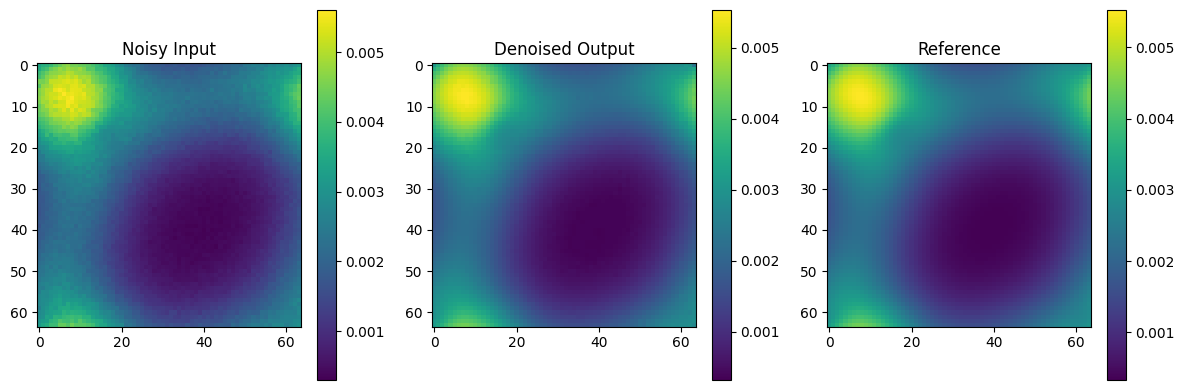

In [16]:
# ------------------------------------------------------------
# Prepare input (single-channel!)
# ------------------------------------------------------------
# test_d shape: (64, 64), noisy density
test_input = test_d[..., None]   # -> (64, 64, 1)

# ------------------------------------------------------------
# Model prediction
# ------------------------------------------------------------
denoised = cae.predict(test_input[np.newaxis, ...])[0, ..., 0]

# ------------------------------------------------------------
# Ground truth
# ------------------------------------------------------------
noisy_input = test_d
true_clean = ref_d

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(noisy_input, cmap='viridis')
plt.title("Noisy Input")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(denoised, cmap='viridis')
plt.title("Denoised Output")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(true_clean, cmap='viridis')
plt.title("Reference")
plt.colorbar()

plt.tight_layout()
plt.show()


In [17]:

# --- Jensen–Shannon divergence ---
print("JSD between noisy and DFT:",
      D_JS(noisy_input, true_clean, tol=1e-16))

print("JSD between denoised and DFT:",
      D_JS(denoised, true_clean, tol=1e-16))

JSD between noisy and DFT: 0.0016519079949543802
JSD between denoised and DFT: 0.00015111373353585475
